# Battery-Constrained Rover Planning: Final Experiment

## Research question

**How do onboard memory, mission size, and time-dependent data degradation affect the feasibility, efficiency, and planning difficulty of a battery-constrained rover mission?**

The rover must travel across terrain, collect and encode scientific datasets, keep them in limited onboard memory, return to base, and offload the data before corruption makes them unusable. Movement also consumes a fixed battery budget.

I used seeds 0–4 while developing and checking the model. After freezing the configuration, I ran the final experiment on unseen seeds 10–14.

### Final experimental design

- Dataset count: 2, 3, or 4
- Memory level: low, medium, or high
- Degradation-margin condition: wide, medium, or tight (stored as low, medium, or high corruption in the experiment files)
- Five seeded replicates in each of the 27 factor combinations
- Final seeds: 10–14
- Battery capacity: 40 energy units
- Planner: ENHSP with `sat-hadd`
- Standard timeout: 30 seconds
- Extended timeout for the three unresolved cases: 120 seconds
- Total final instances: 135

The 30-second runs are used for runtime analysis. The final solved or unsolvable labels are used for feasibility analysis.

### Figures used in the study

The notebook uses five main figures, each answering a different question:

1. How does each experimental factor affect mission success?
2. How do mission size and memory interact?
3. How does mission size affect planner runtime?
4. How does degradation margin change the runtime distribution?
5. How much battery remains after solved missions?

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import (
    binomtest,
    chi2,
    friedmanchisquare,
    wilcoxon,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# Keep text readable after the figures are scaled to one paper column.
plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
    }
)

DATASET_ORDER = [2, 3, 4]
MEMORY_ORDER = ["low", "medium", "high"]
CORRUPTION_ORDER = ["low", "medium", "high"]
STANDARD_STATUS_ORDER = ["solved", "unsolvable", "timeout"]
CLASSIFICATION_STATUS_ORDER = ["solved", "unsolvable"]


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()

    for candidate in [resolved, *resolved.parents]:
        result_file = (
            candidate
            / "experiments"
            / "results"
            / "battery_final_unseen.csv"
        )
        if result_file.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository. Start JupyterLab from the "
        "project folder or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

STANDARD_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen.csv"
)

CLASSIFIED_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen_classified.csv"
)

PLOT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "plots"
    / "battery_final"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "tables"
    / "battery_final"
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths configured.")


Project paths configured.


## 1. Load and validate the final experiment

Two result files are used:

- `battery_final_unseen.csv` contains the original 30-second planner runs;
- `battery_final_unseen_classified.csv` contains the final classification after rerunning only the three timeout cases.

The checks below confirm that the final dataset has the expected size, seeds, model, battery capacity, and valid solved plans.


In [2]:
standard_df = pd.read_csv(STANDARD_RESULTS_PATH)
classified_df = pd.read_csv(CLASSIFIED_RESULTS_PATH)

numeric_columns = [
    "seed",
    "dataset_count",
    "memory_ratio",
    "memory_capacity",
    "total_dataset_size",
    "memory_utilization_ratio",
    "average_travel_time_per_edge",
    "total_one_way_travel_time",
    "optimistic_minimum_energy",
    "battery_capacity",
    "battery_headroom",
    "safe_dataset_count",
    "unsafe_dataset_count",
    "timeout_seconds",
    "wall_runtime_seconds",
    "reported_plan_length",
    "reported_elapsed_time",
    "plan_makespan",
    "travel_time_in_plan",
    "estimated_travel_time",
    "stationary_time",
    "energy_used",
    "battery_remaining",
    "battery_utilization_ratio",
    "action_count",
    "move_actions",
    "collect_actions",
    "offload_actions",
    "waiting_periods",
    "total_waiting_time",
    "standard_runtime_seconds",
    "classification_runtime_seconds",
]

for frame in [standard_df, classified_df]:
    for column in numeric_columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )

for frame in [standard_df, classified_df]:
    frame["dataset_count"] = frame["dataset_count"].astype(int)
    frame["seed"] = frame["seed"].astype(int)
    frame["memory_level"] = pd.Categorical(
        frame["memory_level"],
        categories=MEMORY_ORDER,
        ordered=True,
    )
    frame["corruption_level"] = pd.Categorical(
        frame["corruption_level"],
        categories=CORRUPTION_ORDER,
        ordered=True,
    )

classified_df["standard_status"] = pd.Categorical(
    classified_df["standard_status"],
    categories=STANDARD_STATUS_ORDER,
    ordered=True,
)

classified_df["classification_status"] = pd.Categorical(
    classified_df["classification_status"],
    categories=CLASSIFICATION_STATUS_ORDER,
    ordered=True,
)

display(
    classified_df[
        [
            "instance_id",
            "dataset_count",
            "memory_level",
            "corruption_level",
            "seed",
            "standard_status",
            "classification_status",
            "classification_source",
        ]
    ].head()
)


,instance_id,dataset_count,memory_level,corruption_level,seed,standard_status,classification_status,classification_source
0,rover-battery-n2-mem-low-corr-low-seed-10,2,low,low,10,solved,solved,standard_30s
1,rover-battery-n2-mem-low-corr-low-seed-11,2,low,low,11,solved,solved,standard_30s
2,rover-battery-n2-mem-low-corr-low-seed-12,2,low,low,12,solved,solved,standard_30s
3,rover-battery-n2-mem-low-corr-low-seed-13,2,low,low,13,solved,solved,standard_30s
4,rover-battery-n2-mem-low-corr-low-seed-14,2,low,low,14,solved,solved,standard_30s


In [3]:
assert len(standard_df) == 135, (
    f"Expected 135 standard rows, found {len(standard_df)}."
)
assert len(classified_df) == 135, (
    f"Expected 135 classified rows, found {len(classified_df)}."
)

assert standard_df["instance_id"].is_unique
assert classified_df["instance_id"].is_unique
assert set(standard_df["instance_id"]) == set(classified_df["instance_id"])

assert set(classified_df["dataset_count"]) == set(DATASET_ORDER)
assert set(classified_df["seed"]) == {10, 11, 12, 13, 14}
assert classified_df["model"].eq("battery").all()
assert classified_df["battery_capacity"].eq(40).all()
assert classified_df["unsafe_dataset_count"].fillna(0).eq(0).all()

standard_counts = (
    classified_df["standard_status"]
    .value_counts()
    .reindex(STANDARD_STATUS_ORDER, fill_value=0)
)

classification_counts = (
    classified_df["classification_status"]
    .value_counts()
    .reindex(CLASSIFICATION_STATUS_ORDER, fill_value=0)
)

assert int(standard_counts["timeout"]) == 3
assert classified_df["classification_status"].notna().all()
assert classified_df["classification_source"].eq(
    "extended_120s"
).sum() == 3

solved_rows = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

battery_valid = (
    solved_rows["battery_feasible"]
    .astype(str)
    .str.lower()
    .eq("true")
)

route_valid = (
    solved_rows["route_metrics_valid"]
    .astype(str)
    .str.lower()
    .eq("true")
)

assert battery_valid.all()
assert route_valid.all()
assert solved_rows["battery_remaining"].ge(-1e-9).all()

print("Final experiment validation passed.")
print("Standard 30-second outcomes:")
display(standard_counts.rename("instances").to_frame())
print("Final feasibility classifications:")
display(classification_counts.rename("instances").to_frame())


Final experiment validation passed.
Standard 30-second outcomes:


,instances
standard_status,
solved,107
unsolvable,25
timeout,3


Final feasibility classifications:


,instances
classification_status,
solved,108
unsolvable,27


## 2. Planner outcomes and timeout classification

A timeout is not treated as proof that a mission is unsolvable. The three missions that reached the 30-second limit were rerun with a 120-second limit. The table shows how the original outcomes changed after this final classification step.


In [4]:
status_table = pd.DataFrame(
    {
        "Standard 30-second outcome": standard_counts,
        "Final classification": (
            classification_counts
            .reindex(STANDARD_STATUS_ORDER, fill_value=0)
        ),
    }
)

display(status_table)

extended_cases = classified_df[
    classified_df["classification_source"].eq("extended_120s")
][
    [
        "instance_id",
        "standard_status",
        "standard_runtime_seconds",
        "classification_status",
        "classification_runtime_seconds",
        "plan_makespan",
    ]
].copy()

print("Cases rerun with the 120-second limit")
display(extended_cases)


,Standard 30-second outcome,Final classification
solved,107,108
unsolvable,25,27
timeout,3,0


Cases rerun with the 120-second limit


,instance_id,standard_status,standard_runtime_seconds,classification_status,classification_runtime_seconds,plan_makespan
92,rover-battery-n4-mem-low-corr-low-seed-12,timeout,30.107204,unsolvable,73.727800,NaN
94,rover-battery-n4-mem-low-corr-low-seed-14,timeout,30.109172,unsolvable,77.297805,NaN
123,rover-battery-n4-mem-high-corr-low-seed-13,timeout,30.119575,solved,35.325328,23.0


The standard experiment produced 107 solved cases, 25 unsolvable cases, and 3 timeouts. After the longer reruns, the final classification contained 108 solved missions and 27 unsolvable missions, with no unresolved cases.


## 3. Mission feasibility

This section studies whether a valid mission plan exists. Feasibility is compared across mission size, memory level, and degradation margin. The interaction between dataset count and memory is especially important because memory may have little effect on small missions but become critical as the workload grows.


In [5]:
def summarize_feasibility(
    frame: pd.DataFrame,
    group_columns,
) -> pd.DataFrame:
    """Count classified outcomes and calculate mission success rate."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    records = []

    for keys, group in frame.groupby(
        group_columns,
        observed=True,
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_columns, keys))
        statuses = group["classification_status"].astype(str)

        solved = int(statuses.eq("solved").sum())
        unsolvable = int(statuses.eq("unsolvable").sum())
        total = len(group)

        record.update(
            {
                "instances": total,
                "solved": solved,
                "unsolvable": unsolvable,
                "success_rate": solved / total,
                "success_percent": 100 * solved / total,
            }
        )
        records.append(record)

    return pd.DataFrame(records)


success_by_dataset = summarize_feasibility(
    classified_df,
    "dataset_count",
).sort_values("dataset_count")

success_by_memory = summarize_feasibility(
    classified_df,
    "memory_level",
)

success_by_corruption = summarize_feasibility(
    classified_df,
    "corruption_level",
)

success_dataset_memory = summarize_feasibility(
    classified_df,
    ["dataset_count", "memory_level"],
).sort_values(["dataset_count", "memory_level"])

print("Success by dataset count")
display(success_by_dataset)

print("Success by memory level")
display(success_by_memory)

print("Success by degradation-margin condition")
display(success_by_corruption)

print("Dataset-count × memory interaction")
display(success_dataset_memory)


Success by dataset count


,dataset_count,instances,solved,unsolvable,success_rate,success_percent
0,2,45,45,0,1.0,100.0
1,3,45,36,9,0.8,80.0
2,4,45,27,18,0.6,60.0


Success by memory level


,memory_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,21,24,0.466667,46.666667
1,medium,45,42,3,0.933333,93.333333
2,high,45,45,0,1.000000,100.000000


Success by degradation-margin condition


,corruption_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,36,9,0.8,80.0
1,medium,45,36,9,0.8,80.0
2,high,45,36,9,0.8,80.0


Dataset-count × memory interaction


,dataset_count,memory_level,instances,solved,unsolvable,success_rate,success_percent
2,2,high,15,15,0,1.0,100.0
0,2,low,15,15,0,1.0,100.0
1,2,medium,15,15,0,1.0,100.0
5,3,high,15,15,0,1.0,100.0
3,3,low,15,6,9,0.4,40.0
4,3,medium,15,15,0,1.0,100.0
8,4,high,15,15,0,1.0,100.0
6,4,low,15,0,15,0.0,0.0
7,4,medium,15,12,3,0.8,80.0


In [6]:
def wilson_interval(
    successes: int,
    total: int,
    z_value: float = 1.959963984540054,
) -> tuple:
    if total <= 0:
        return np.nan, np.nan

    proportion = successes / total
    denominator = 1 + z_value**2 / total
    center = (
        proportion + z_value**2 / (2 * total)
    ) / denominator
    radius = (
        z_value
        * np.sqrt(
            proportion * (1 - proportion) / total
            + z_value**2 / (4 * total**2)
        )
        / denominator
    )

    return max(0.0, center - radius), min(1.0, center + radius)


def success_with_wilson(
    factor: str,
    order,
    factor_label: str,
    label_function,
) -> pd.DataFrame:
    rows = []

    for level in order:
        subset = classified_df[
            classified_df[factor].astype(str).eq(str(level))
        ]
        statuses = subset["classification_status"].astype(str)
        solved = int(statuses.eq("solved").sum())
        total = len(subset)
        lower, upper = wilson_interval(solved, total)

        rows.append(
            {
                "factor": factor_label,
                "level": level,
                "label": label_function(level),
                "solved": solved,
                "total": total,
                "success_percent": 100 * solved / total,
                "ci_low_percent": 100 * lower,
                "ci_high_percent": 100 * upper,
            }
        )

    return pd.DataFrame(rows)


success_rates_wilson = pd.concat(
    [
        success_with_wilson(
            "dataset_count",
            DATASET_ORDER,
            "Dataset count",
            lambda value: f"{value} datasets",
        ),
        success_with_wilson(
            "memory_level",
            MEMORY_ORDER,
            "Memory",
            lambda value: f"{str(value).title()} memory",
        ),
        success_with_wilson(
            "corruption_level",
            CORRUPTION_ORDER,
            "Degradation margin",
            lambda value: {
                "low": "Wide margin (10–14)",
                "medium": "Medium margin (6–10)",
                "high": "Tight margin (3–5)",
            }[str(value)],
        ),
    ],
    ignore_index=True,
)

display(success_rates_wilson)


,factor,level,label,solved,total,success_percent,ci_low_percent,ci_high_percent
0,Dataset count,2,2 datasets,45,45,100.000000,92.134840,100.000000
1,Dataset count,3,3 datasets,36,45,80.000000,66.177031,89.103873
2,Dataset count,4,4 datasets,27,45,60.000000,45.451855,72.975113
3,Memory,low,Low memory,21,45,46.666667,32.935132,60.922545
4,Memory,medium,Medium memory,42,45,93.333333,82.143398,97.706797
5,Memory,high,High memory,45,45,100.000000,92.134840,100.000000
6,Degradation margin,low,Wide margin (10–14),36,45,80.000000,66.177031,89.103873
7,Degradation margin,medium,Medium margin (6–10),36,45,80.000000,66.177031,89.103873
8,Degradation margin,high,Tight margin (3–5),36,45,80.000000,66.177031,89.103873


### Paper Figure 2 — Mission success by factor

This is Figure 2 in the paper. Each point is the observed success rate
for 45 missions. The horizontal bar is a 95% Wilson confidence interval,
which shows the uncertainty around that percentage.

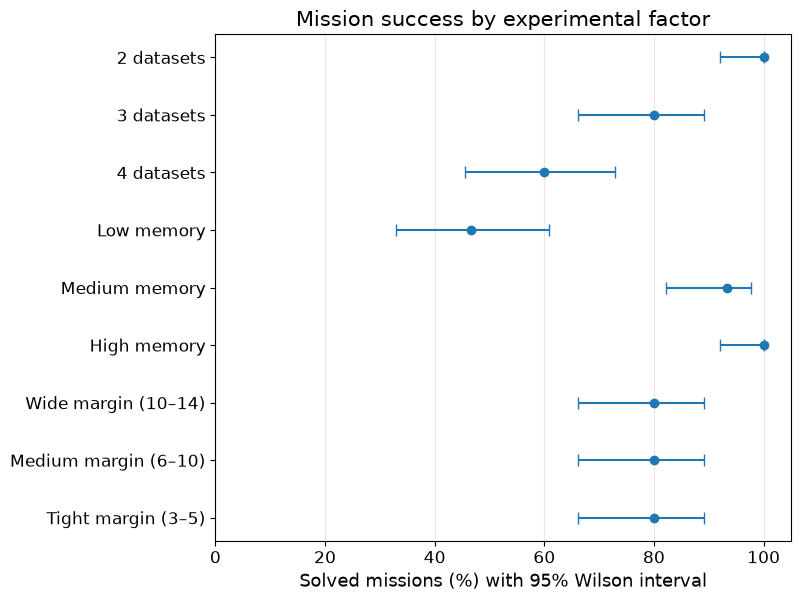

In [7]:
plot_df = success_rates_wilson.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(plot_df))
estimates = plot_df["success_percent"].to_numpy()
errors = np.vstack(
    [
        estimates - plot_df["ci_low_percent"].to_numpy(),
        plot_df["ci_high_percent"].to_numpy() - estimates,
    ]
)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.errorbar(
    estimates,
    positions,
    xerr=errors,
    fmt="o",
    capsize=4,
    linewidth=1.5,
)
ax.set_yticks(positions, plot_df["label"])
ax.set_xlim(0, 105)
ax.set_xlabel("Solved missions (%) with 95% Wilson interval")
ax.set_title("Mission success by experimental factor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_rates_wilson_95.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Paper Figure 3 — Dataset-count and memory interaction

This heatmap makes the interaction easy to see. Memory has little effect
for the smallest workload, but it becomes decisive as the rover must
handle more datasets. The percentages are feasibility rates, not runtime
or plan-quality scores.

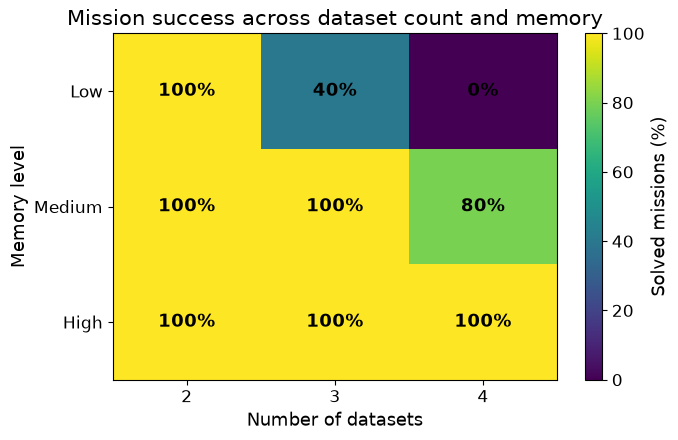

In [8]:
interaction_matrix = (
    success_dataset_memory.pivot(
        index="memory_level",
        columns="dataset_count",
        values="success_percent",
    )
    .reindex(index=MEMORY_ORDER, columns=DATASET_ORDER)
)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
image = ax.imshow(
    interaction_matrix.to_numpy(),
    vmin=0,
    vmax=100,
    aspect="auto",
)
ax.set_title("Mission success across dataset count and memory")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Memory level")
ax.set_xticks(range(len(DATASET_ORDER)), DATASET_ORDER)
ax.set_yticks(
    range(len(MEMORY_ORDER)),
    [level.title() for level in MEMORY_ORDER],
)

for row_index in range(interaction_matrix.shape[0]):
    for column_index in range(interaction_matrix.shape[1]):
        value = interaction_matrix.iloc[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f"{value:.0f}%",
            ha="center",
            va="center",
            fontweight="bold",
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Solved missions (%)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_interaction_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Feasibility result

#### How to read Figure 2

Each row contains 45 missions. The dot is the observed success percentage and the horizontal line is its 95% Wilson interval. The interval represents uncertainty around the percentage; it is not the minimum and maximum result of individual missions.

The workload pattern is direct: all two-dataset missions were solved, compared with 80% of three-dataset missions and 60% of four-dataset missions. Memory shows an even larger difference, from 46.7% success at low memory to 100% at high memory.

The three degradation-margin rows all show 80% success. This does not mean that data degradation was disabled. Every collected dataset still had a loss deadline. It means that changing the tested positive margin did not move the solved/unsolved boundary for these matched missions.

#### How to read Figure 3

Every heatmap cell contains 15 missions. Yellow means high success and dark purple means low success. Reading across each row shows what happens when the number of datasets increases at a fixed memory level.

Memory has no visible effect with two datasets because all settings are sufficient. The interaction appears when the workload grows: low memory falls to 40% success with three datasets and 0% with four, while high memory remains at 100%. The correct conclusion is therefore not simply "more memory is better." Memory becomes a bottleneck when the mission is large enough.

## 4. Planner runtime

Runtime is analysed using the original 30-second runs only. The later 120-second reruns are excluded so that every runtime value comes from the same computational budget.

The figure compares two values for each mission size:

- the **median**, which represents a typical run;
- the **90th percentile**, which shows the slower end of the distribution without using only the single worst case.


In [9]:
runtime_df = standard_df.copy()
runtime_df["runtime_30s_seconds"] = runtime_df["wall_runtime_seconds"]

runtime_by_dataset = (
    runtime_df.groupby("dataset_count", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

runtime_by_corruption = (
    runtime_df.groupby("corruption_level", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

print("Runtime by dataset count")
display(runtime_by_dataset)

print("Runtime by degradation margin")
display(runtime_by_corruption)


Runtime by dataset count


,dataset_count,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,2,45,0.398100,0.383965,0.448662,0.481760,0
1,3,45,0.797414,0.528247,1.754688,3.438560,0
2,4,45,9.357990,7.314771,25.345049,30.119575,3


Runtime by degradation margin


,corruption_level,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,low,45,6.252784,0.532860,25.136196,30.119575,3
1,medium,45,3.286430,0.534489,9.471424,28.444092,0
2,high,45,1.014290,0.458232,2.644699,5.286685,0


### Paper Figure 4 — Runtime by mission size

This is Figure 4 in the paper. The median describes a typical run, while
the 90th percentile exposes the slow tail. The logarithmic y-axis is used
because the largest runtimes are much greater than the smallest ones.

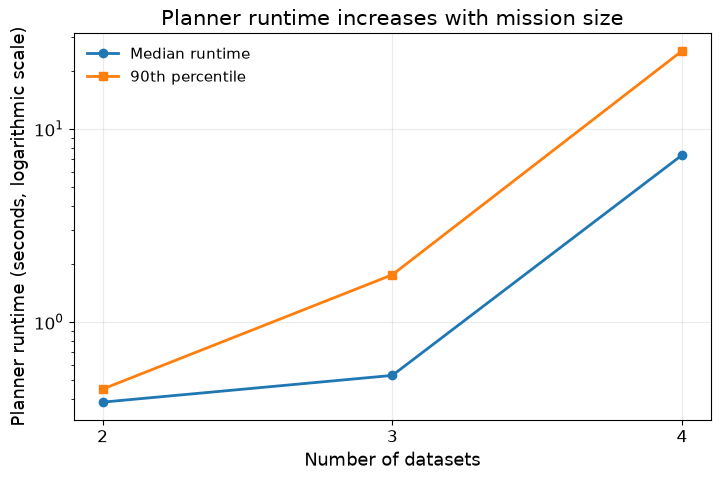

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

ax.plot(
    runtime_by_dataset["dataset_count"],
    runtime_by_dataset["median_runtime"],
    marker="o",
    linewidth=2,
    label="Median runtime",
)

ax.plot(
    runtime_by_dataset["dataset_count"],
    runtime_by_dataset["p90_runtime"],
    marker="s",
    linewidth=2,
    label="90th percentile",
)

ax.set_yscale("log")
ax.set_xticks(DATASET_ORDER)
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Planner runtime (seconds, logarithmic scale)")
ax.set_title("Planner runtime increases with mission size")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_summary_by_dataset_count.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Paper Figure 5 — Runtime distribution by degradation margin

This is the exact ECDF used as Figure 5 in the paper.

- The x-axis is planner runtime on a logarithmic scale.
- The y-axis is the fraction of runs whose observed runtime is at or
  below the x-axis value.
- A curve farther left means that its runs generally finished sooner.
- The tight-margin curve is concentrated on the left. The wide-margin
  curve has the heaviest right tail, so some wide-margin runs required
  much more search time.

This figure describes planning difficulty. It does not claim that a
wider margin changes final mission feasibility.

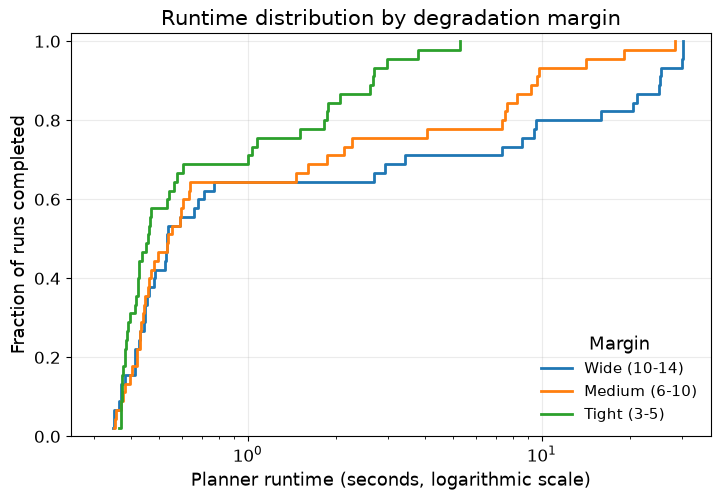

In [11]:
margin_labels = {
    "low": "Wide (10-14)",
    "medium": "Medium (6-10)",
    "high": "Tight (3-5)",
}

fig, ax = plt.subplots(figsize=(7.4, 5.2))

for level in CORRUPTION_ORDER:
    values = np.sort(
        runtime_df.loc[
            runtime_df["corruption_level"]
            .astype(str)
            .eq(level),
            "runtime_30s_seconds",
        ].to_numpy()
    )
    cumulative = np.arange(1, len(values) + 1) / len(values)
    ax.step(
        values,
        cumulative,
        where="post",
        linewidth=2,
        label=margin_labels[level],
    )

ax.set_xscale("log")
ax.set_xlim(left=0.25)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Planner runtime (seconds, logarithmic scale)")
ax.set_ylabel("Fraction of runs completed")
ax.set_title("Runtime distribution by degradation margin")
ax.grid(alpha=0.25)
ax.legend(title="Margin", frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_ecdf_by_degradation_margin.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Runtime result

#### How to read Figure 4

Figure 4 compares the median runtime with the 90th percentile for each mission size. The median describes a typical run. The 90th percentile describes the slower end: 90% of runs finished at or below that value. The vertical axis is logarithmic, so equal vertical distances represent multiplicative rather than additive changes.

Two-dataset missions were fast and consistent. Four-dataset missions had a median runtime of 7.315 seconds and a 90th percentile of 25.345 seconds. All three standard 30-second timeouts occurred in four-dataset missions.

#### How to read Figure 5

Figure 5 is an empirical cumulative distribution. At any runtime on the horizontal axis, the curve height gives the fraction of runs with a recorded runtime at or below that value. A curve that rises earlier and stays further left represents faster planning.

The tight-margin curve rises fastest and finishes its tail early. The wide-margin curve has the longest tail; all three standard timeouts are in that condition. Mean runtime was 1.014 seconds for tight margins, 3.286 seconds for medium margins, and 6.253 seconds for wide margins.

This does not contradict the equal 80% feasibility rates. The margins did not change which matched missions were ultimately solvable, but they changed how long ENHSP searched. Wider deadlines may leave more candidate schedules to explore, whereas tight deadlines may reject alternatives earlier. That pruning explanation is plausible, but it remains a hypothesis because ENHSP's internal search nodes were not recorded.

## 5. Plan efficiency and battery use

Plan metrics exist only for missions where ENHSP found a plan. They describe the generated satisficing plans and are not claimed to be globally optimal.

The figure in this section shows the battery left after solved missions. The matched analysis later compares movement count, energy use, and makespan only on mission blocks solved under all three memory settings.

In [12]:
solved_plans = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

plan_metrics_by_memory = (
    solved_plans.groupby("memory_level", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
        mean_battery_utilization=(
            "battery_utilization_ratio",
            "mean",
        ),
    )
    .reset_index()
)

plan_metrics_by_dataset = (
    solved_plans.groupby("dataset_count", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
    )
    .reset_index()
)

print("Solved-plan metrics by memory")
display(plan_metrics_by_memory)

print("Solved-plan metrics by dataset count")
display(plan_metrics_by_dataset)

final_solved_plans = solved_plans[
    solved_plans["energy_used"].notna()
    & solved_plans["battery_remaining"].notna()
    & solved_plans["plan_makespan"].notna()
].copy()


Solved-plan metrics by memory


,memory_level,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining,mean_battery_utilization
0,low,21,25.761905,24.0,7.714286,6.0,24.571429,24.0,15.428571,16.0,0.614286
1,medium,42,28.119048,29.0,8.952381,10.0,30.476190,31.0,9.523810,9.0,0.761905
2,high,45,23.822222,24.0,7.777778,8.0,26.577778,28.0,13.422222,12.0,0.664444


Solved-plan metrics by dataset count


,dataset_count,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining
0,2,45,19.044444,19.0,5.333333,6.0,18.266667,18.0,21.733333,22.0
1,3,36,30.027778,30.0,9.777778,10.0,31.555556,34.0,8.444444,6.0
2,4,27,31.703704,32.0,10.962963,10.0,38.296296,40.0,1.703704,0.0


### Paper Figure 6 — Battery remaining by mission size

This is Figure 6 in the paper. Each point is one solved mission and each
box summarizes the distribution for that dataset count. Values near zero
mean that the generated plan used almost all of the fixed battery budget.

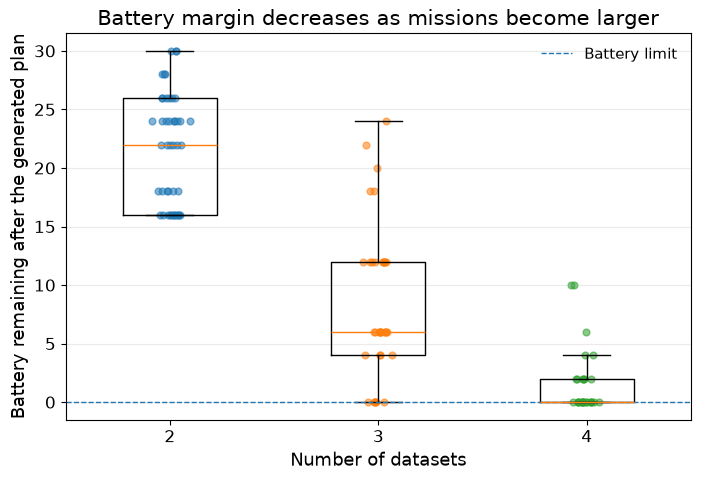

In [13]:
# Battery remaining by mission size
battery_groups = [
    final_solved_plans.loc[
        final_solved_plans["dataset_count"].eq(dataset_count),
        "battery_remaining",
    ].to_numpy()
    for dataset_count in DATASET_ORDER
]

fig, ax = plt.subplots(figsize=(7.2, 5.0))

ax.boxplot(
    battery_groups,
    positions=DATASET_ORDER,
    widths=0.45,
    showfliers=False,
)

rng = np.random.default_rng(42)

for dataset_count, values in zip(DATASET_ORDER, battery_groups):
    jitter = rng.normal(
        loc=dataset_count,
        scale=0.045,
        size=len(values),
    )
    ax.scatter(
        jitter,
        values,
        alpha=0.55,
        s=24,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="Battery limit",
)

ax.set_xticks(DATASET_ORDER)
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Battery remaining after the generated plan")
ax.set_title("Battery margin decreases as missions become larger")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "battery_remaining_by_dataset_count.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Plan-efficiency result

#### How to read Figure 6

Each dot represents one solved mission. The box contains the middle half of the observations, and the orange line inside the box is the median. The dashed line at zero is the battery boundary.

Two-dataset plans usually retained a comfortable battery margin. Three-dataset plans had much less energy left, and most four-dataset plans finished at or very close to zero. The mean remaining battery fell from 21.73 units for two datasets to 8.44 for three and 1.70 for four.

This graph contains solved missions only. It must not be used to claim that every four-dataset mission nearly succeeded; failed missions have no returned plan and therefore no final battery value in this figure.

All 108 final solved plans passed the independent route and battery checks. For the memory-efficiency comparison, the notebook uses only 21 complete blocks where low, medium, and high memory all produced a plan. That matched comparison shows that additional memory reduced movement count, energy use, and makespan in ENHSP's returned plans. Since `sat-hadd` is satisficing, these values describe the plans that were found; they are not guaranteed global optima.

## 6. Statistical analysis

The statistical tests are exploratory because the experiment uses synthetic missions and five seeded replicates per cell.

- Cochran's Q compares final feasibility across matched factor levels.
- Exact McNemar tests with Holm adjustment provide paired feasibility follow-ups.
- Friedman tests compare matched runtime distributions and matched plan metrics.
- Wilcoxon signed-rank follow-ups use Holm adjustment.
- Kendall's W is reported with the Friedman tests.

The matched design is important: missions with the same seed and remaining factor settings share terrain and dataset properties, so treating every row as an unrelated observation would discard useful pairing information.

In [14]:
from itertools import combinations


def holm_adjust(p_values: list[float]) -> list[float]:
    order = sorted(range(len(p_values)), key=p_values.__getitem__)
    adjusted = [np.nan] * len(p_values)
    previous = 0.0

    for rank, index in enumerate(order):
        value = min(
            1.0,
            p_values[index] * (len(p_values) - rank),
        )
        value = max(previous, value)
        adjusted[index] = value
        previous = value

    return adjusted


def matched_pivot(
    frame: pd.DataFrame,
    factor: str,
    order,
    block_columns,
    value: str,
) -> pd.DataFrame:
    return (
        frame.pivot(
            index=block_columns,
            columns=factor,
            values=value,
        )
        .reindex(columns=order)
        .dropna()
    )


def cochran_q(pivot: pd.DataFrame) -> tuple[float, float]:
    values = pivot.to_numpy(dtype=float)
    treatment_count = values.shape[1]
    treatment_totals = values.sum(axis=0)
    block_totals = values.sum(axis=1)
    grand_total = values.sum()

    denominator = (
        treatment_count * grand_total
        - np.square(block_totals).sum()
    )

    if denominator == 0:
        return 0.0, 1.0

    numerator = (treatment_count - 1) * (
        treatment_count * np.square(treatment_totals).sum()
        - grand_total**2
    )
    statistic = numerator / denominator

    return statistic, chi2.sf(
        statistic,
        treatment_count - 1,
    )


def exact_mcnemar_results(
    pivot: pd.DataFrame,
    factor_label: str,
) -> pd.DataFrame:
    records = []

    for first, second in combinations(pivot.columns, 2):
        first_only = int(
            (
                (pivot[first] == 1)
                & (pivot[second] == 0)
            ).sum()
        )
        second_only = int(
            (
                (pivot[first] == 0)
                & (pivot[second] == 1)
            ).sum()
        )
        discordant = first_only + second_only
        p_value = (
            binomtest(
                min(first_only, second_only),
                discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
            if discordant
            else 1.0
        )
        records.append(
            {
                "factor": factor_label,
                "level_1": first,
                "level_2": second,
                "level_1_only_solved": first_only,
                "level_2_only_solved": second_only,
                "discordant_blocks": discordant,
                "p_value": p_value,
            }
        )

    result = pd.DataFrame(records)
    result["holm_adjusted_p"] = holm_adjust(
        result["p_value"].tolist()
    )
    return result


def paired_wilcoxon_results(
    pivot: pd.DataFrame,
    analysis: str,
) -> pd.DataFrame:
    records = []

    for first, second in combinations(pivot.columns, 2):
        result = wilcoxon(
            pivot[first],
            pivot[second],
            zero_method="pratt",
            alternative="two-sided",
            method="auto",
        )
        records.append(
            {
                "analysis": analysis,
                "level_1": first,
                "level_2": second,
                "statistic": result.statistic,
                "p_value": result.pvalue,
                "median_paired_difference": (
                    pivot[first] - pivot[second]
                ).median(),
                "matched_blocks": len(pivot),
            }
        )

    result = pd.DataFrame(records)
    result["holm_adjusted_p"] = holm_adjust(
        result["p_value"].tolist()
    )
    return result


classified_df["final_solved_binary"] = (
    classified_df["classification_status"]
    .astype(str)
    .eq("solved")
    .astype(int)
)

factor_specs = [
    (
        "dataset_count",
        DATASET_ORDER,
        ["memory_level", "corruption_level", "seed"],
        "Dataset count",
    ),
    (
        "memory_level",
        MEMORY_ORDER,
        ["dataset_count", "corruption_level", "seed"],
        "Memory level",
    ),
    (
        "corruption_level",
        CORRUPTION_ORDER,
        ["dataset_count", "memory_level", "seed"],
        "Degradation margin",
    ),
]

statistical_results = []
feasibility_pairwise_frames = []
runtime_pairwise_frames = []

for factor, order, blocks, label in factor_specs:
    feasibility_pivot = matched_pivot(
        classified_df,
        factor,
        order,
        blocks,
        "final_solved_binary",
    )
    statistic, p_value = cochran_q(feasibility_pivot)
    discordant_blocks = int(
        (
            (feasibility_pivot.sum(axis=1) > 0)
            & (
                feasibility_pivot.sum(axis=1)
                < len(feasibility_pivot.columns)
            )
        ).sum()
    )
    statistical_results.append(
        {
            "analysis": (
                f"Matched feasibility difference: {factor}"
            ),
            "test": "Cochran's Q",
            "statistic": statistic,
            "p_value": p_value,
            "degrees_of_freedom": len(order) - 1,
            "effect_size_name": "",
            "effect_size": np.nan,
            "sample_size": len(feasibility_pivot),
            "notes": (
                f"{discordant_blocks} discordant matched blocks."
            ),
        }
    )
    feasibility_pairwise_frames.append(
        exact_mcnemar_results(feasibility_pivot, label)
    )

    runtime_pivot = matched_pivot(
        runtime_df,
        factor,
        order,
        blocks,
        "runtime_30s_seconds",
    )
    statistic, p_value = friedmanchisquare(
        *[runtime_pivot[level] for level in order]
    )
    kendalls_w = statistic / (
        len(runtime_pivot) * (len(order) - 1)
    )
    statistical_results.append(
        {
            "analysis": (
                f"Matched standard runtime difference: {factor}"
            ),
            "test": "Friedman",
            "statistic": statistic,
            "p_value": p_value,
            "degrees_of_freedom": len(order) - 1,
            "effect_size_name": "Kendall's W",
            "effect_size": kendalls_w,
            "sample_size": len(runtime_pivot),
            "notes": (
                "Matched 30-second runs; timeout runtimes "
                "remain near the fixed limit."
            ),
        }
    )
    runtime_pairwise_frames.append(
        paired_wilcoxon_results(
            runtime_pivot,
            f"Standard runtime: {factor}",
        )
    )

statistical_results_df = pd.DataFrame(statistical_results)
feasibility_pairwise_tests = pd.concat(
    feasibility_pairwise_frames,
    ignore_index=True,
)
runtime_pairwise_tests = pd.concat(
    runtime_pairwise_frames,
    ignore_index=True,
)

display(statistical_results_df)
display(feasibility_pairwise_tests)

,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Matched feasibility difference: dataset_count,Cochran's Q,27.000000,1.370959e-06,2,,NaN,45,18 discordant matched blocks.
1,Matched standard runtime difference: dataset_c...,Friedman,86.177778,1.935233e-19,2,Kendall's W,0.957531,45,Matched 30-second runs; timeout runtimes remai...
2,Matched feasibility difference: memory_level,Cochran's Q,42.750000,5.211412e-10,2,,NaN,45,24 discordant matched blocks.
3,Matched standard runtime difference: memory_level,Friedman,24.577778,4.602601e-06,2,Kendall's W,0.273086,45,Matched 30-second runs; timeout runtimes remai...
4,Matched feasibility difference: corruption_level,Cochran's Q,0.000000,1.000000e+00,2,,NaN,45,0 discordant matched blocks.
5,Matched standard runtime difference: corruptio...,Friedman,36.044444,1.489527e-08,2,Kendall's W,0.400494,45,Matched 30-second runs; timeout runtimes remai...


,factor,level_1,level_2,level_1_only_solved,level_2_only_solved,discordant_blocks,p_value,holm_adjusted_p
0,Dataset count,2,3,9,0,9,3.906250e-03,7.812500e-03
1,Dataset count,2,4,18,0,18,7.629395e-06,2.288818e-05
2,Dataset count,3,4,9,0,9,3.906250e-03,7.812500e-03
3,Memory level,low,medium,0,21,21,9.536743e-07,1.907349e-06
4,Memory level,low,high,0,24,24,1.192093e-07,3.576279e-07
5,Memory level,medium,high,0,3,3,2.500000e-01,2.500000e-01
6,Degradation margin,low,medium,0,0,0,1.000000e+00,1.000000e+00
7,Degradation margin,low,high,0,0,0,1.000000e+00,1.000000e+00
8,Degradation margin,medium,high,0,0,0,1.000000e+00,1.000000e+00


In [15]:
def matched_memory_pivot(metric: str) -> pd.DataFrame:
    return (
        solved_plans.pivot_table(
            index=[
                "dataset_count",
                "corruption_level",
                "seed",
            ],
            columns="memory_level",
            values=metric,
            aggfunc="first",
            observed=True,
        )
        .reindex(columns=MEMORY_ORDER)
        .dropna()
    )


def run_matched_memory_test(metric: str) -> dict:
    pivot = matched_memory_pivot(metric)
    statistic, p_value = friedmanchisquare(
        pivot["low"],
        pivot["medium"],
        pivot["high"],
    )
    kendalls_w = statistic / (
        len(pivot) * (len(MEMORY_ORDER) - 1)
    )

    return {
        "analysis": f"Matched memory comparison: {metric}",
        "test": "Friedman",
        "statistic": statistic,
        "p_value": p_value,
        "degrees_of_freedom": 2,
        "effect_size_name": "Kendall's W",
        "effect_size": kendalls_w,
        "sample_size": len(pivot),
        "notes": (
            "Complete blocks where all three memory variants "
            "were solved."
        ),
    }


plan_metrics = [
    "move_actions",
    "energy_used",
    "plan_makespan",
]

matched_tests = pd.DataFrame(
    [
        run_matched_memory_test(metric)
        for metric in plan_metrics
    ]
)

plan_metric_pairwise_tests = pd.concat(
    [
        paired_wilcoxon_results(
            matched_memory_pivot(metric),
            f"Matched memory comparison: {metric}",
        )
        for metric in plan_metrics
    ],
    ignore_index=True,
)

statistical_results_df = pd.concat(
    [statistical_results_df, matched_tests],
    ignore_index=True,
)

display(matched_tests)
display(plan_metric_pairwise_tests)

,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Matched memory comparison: move_actions,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,Complete blocks where all three memory variant...
1,Matched memory comparison: energy_used,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,Complete blocks where all three memory variant...
2,Matched memory comparison: plan_makespan,Friedman,34.238806,3.673988e-08,2,Kendall's W,0.815210,21,Complete blocks where all three memory variant...


,analysis,level_1,level_2,statistic,p_value,median_paired_difference,matched_blocks,holm_adjusted_p
0,Matched memory comparison: move_actions,low,medium,0.0,0.014306,0.0,21,0.014306
1,Matched memory comparison: move_actions,low,high,0.0,0.000010,2.0,21,0.000031
2,Matched memory comparison: move_actions,medium,high,0.0,0.000055,2.0,21,0.000109
3,Matched memory comparison: energy_used,low,medium,0.0,0.014306,0.0,21,0.014306
4,Matched memory comparison: energy_used,low,high,0.0,0.000035,6.0,21,0.000104
5,Matched memory comparison: energy_used,medium,high,0.0,0.000092,6.0,21,0.000184
6,Matched memory comparison: plan_makespan,low,medium,0.0,0.014699,0.0,21,0.014699
7,Matched memory comparison: plan_makespan,low,high,0.0,0.000057,8.0,21,0.000171
8,Matched memory comparison: plan_makespan,medium,high,6.5,0.000177,6.0,21,0.000354


In [16]:
feasibility_matched_tests = (
    statistical_results_df[
        statistical_results_df["analysis"].str.startswith(
            "Matched feasibility difference:"
        )
    ]
    .copy()
    .reset_index(drop=True)
)

display(feasibility_matched_tests)

,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Matched feasibility difference: dataset_count,Cochran's Q,27.00,1.370959e-06,2,,NaN,45,18 discordant matched blocks.
1,Matched feasibility difference: memory_level,Cochran's Q,42.75,5.211412e-10,2,,NaN,45,24 discordant matched blocks.
2,Matched feasibility difference: corruption_level,Cochran's Q,0.00,1.000000e+00,2,,NaN,45,0 discordant matched blocks.


### Statistical result

The feasibility comparisons use Cochran's Q because the same underlying mission properties are repeated across factor levels. In simple terms, it asks whether the solved/unsolved pattern changes across the matched versions of a mission. Exact McNemar tests then identify which pairs differ.

Dataset count and memory level both changed the matched feasibility pattern. Low memory differed from medium and high memory. Medium and high memory had observed success rates of 93.3% and 100%, but that final pair was not statistically distinguishable with this sample.

All 45 degradation-margin triplets agreed exactly: each matched mission was either solved under all three margins or unsolvable under all three. The correct interpretation is "no feasibility difference inside the tested margin range," not "degradation is irrelevant."

The Friedman runtime test answers a different question and finds a degradation-margin effect. Wide, medium, and tight margins have different matched runtime distributions even though their feasibility is identical. Temporal slack therefore affected ENHSP's search effort without moving the reachability boundary.

Among the 21 complete solved blocks, memory also changed movement count, energy use, and makespan. Every pairwise memory comparison remained significant after Holm adjustment for all three plan metrics.

## 7. Export the analysis results

The notebook saves the result tables and the five main figures used to explain the study.


In [17]:
exports = {
    "status_standard_vs_classified.csv": (
        status_table.reset_index().rename(
            columns={"index": "status"}
        )
    ),
    "extended_classifications.csv": extended_cases,
    "success_by_dataset_count.csv": success_by_dataset,
    "success_by_memory.csv": success_by_memory,
    "success_by_corruption.csv": success_by_corruption,
    "success_dataset_memory_interaction.csv": (
        success_dataset_memory
    ),
    "success_rates_wilson_95.csv": success_rates_wilson,
    "runtime_by_dataset_count.csv": runtime_by_dataset,
    "runtime_by_corruption.csv": runtime_by_corruption,
    "solved_plan_metrics_by_memory.csv": (
        plan_metrics_by_memory
    ),
    "solved_plan_metrics_by_dataset_count.csv": (
        plan_metrics_by_dataset
    ),
    "statistical_tests.csv": statistical_results_df,
    "feasibility_matched_tests.csv": (
        feasibility_matched_tests
    ),
    "feasibility_pairwise_mcnemar.csv": (
        feasibility_pairwise_tests
    ),
    "runtime_pairwise_wilcoxon.csv": (
        runtime_pairwise_tests
    ),
    "plan_metric_pairwise_wilcoxon.csv": (
        plan_metric_pairwise_tests
    ),
}

for filename, table in exports.items():
    table.to_csv(
        TABLE_DIR / filename,
        index=False,
    )

expected_plots = [
    "success_rates_wilson_95.png",
    "success_interaction_heatmap.png",
    "runtime_summary_by_dataset_count.png",
    "runtime_ecdf_by_degradation_margin.png",
    "battery_remaining_by_dataset_count.png",
]

missing_plots = [
    filename
    for filename in expected_plots
    if not (PLOT_DIR / filename).exists()
]

assert not missing_plots, f"Missing plots: {missing_plots}"

print(f"Saved {len(exports)} analysis tables.")
print(f"Saved {len(expected_plots)} main figures.")

Saved 16 analysis tables.
Saved 5 main figures.


## 8. Conclusions

The final experiment gives four main results:

1. **Larger missions are harder.** Increasing the workload from two to four datasets reduced feasibility, increased planner runtime, and reduced the remaining battery margin.
2. **Memory is the main reachability bottleneck.** Its effect becomes visible as workload grows. In matched solved missions, more memory also reduces extra trips, movement energy, and makespan.
3. **Degradation margin affects search differently from feasibility.** All three margins produce the same matched solved/unsolved pattern, but wide margins have a much heavier planner-runtime tail.
4. **The constraints interact.** Memory changes how often the rover must return to base. Those trips change battery use and elapsed time, while the degradation deadline determines whether collected data can still be offloaded.

Two cautions are important. First, adding a dataset also adds another site to the linear map, so the workload factor combines more science tasks with greater spatial extent. Second, ENHSP `sat-hadd` returns satisficing plans; the reported energy and makespan values are not proofs of optimality.

The overall conclusion is that no rover resource should be interpreted alone. The tested degradation margins did not decide reachability, but degradation remained an active deadline and affected planning difficulty. In this parameter range, memory and battery reached their limits first.

## 9. ROS 2 demonstration

The notebook now sends one request to the same ROS 2 service used by the project. The returned battery values are checked and saved as a reproducibility table.

Start the ROS 2 experiment service in a separate terminal before running the next cell.


In [18]:
import json
import subprocess

ros_command = f"""
source /opt/ros/jazzy/setup.bash
source "{PROJECT_ROOT}/ros2_ws/install/setup.bash"
cd "{PROJECT_ROOT}"

ros2 run rover_experiment_ros experiment_client \
  --datasets 3 \
  --memory medium \
  --corruption medium \
  --seed 0 \
  --timeout 30
"""

completed = subprocess.run(
    ["bash", "-lc", ros_command],
    capture_output=True,
    text=True,
    timeout=45,
    check=False,
)

if completed.returncode != 0:
    raise RuntimeError(
        "ROS 2 experiment client failed.\n\n"
        f"Standard output:\n{completed.stdout}\n\n"
        f"Standard error:\n{completed.stderr}"
    )

output_text = completed.stdout.strip()

json_start = output_text.find("{")
json_end = output_text.rfind("}")

if json_start < 0 or json_end < json_start:
    raise RuntimeError(
        "Could not find the JSON result in the ROS client output:\n"
        + output_text
    )

ros_result = json.loads(
    output_text[json_start:json_end + 1]
)

ros_result_table = pd.DataFrame([ros_result])

display(
    ros_result_table[
        [
            "instance_id",
            "status",
            "wall_runtime_seconds",
            "plan_makespan",
            "action_count",
            "move_actions",
            "battery_capacity",
            "energy_used",
            "battery_remaining",
            "battery_feasible",
        ]
    ]
)

assert ros_result["instance_id"] == (
    "rover-battery-n3-mem-medium-corr-medium-seed-0"
)
assert ros_result["status"] == "solved"
assert ros_result["solved"] is True
assert ros_result["battery_feasible"] is True
assert ros_result["battery_capacity"] > 0
assert ros_result["energy_used"] >= 0
assert ros_result["battery_remaining"] >= 0

calculated_remaining = (
    ros_result["battery_capacity"]
    - ros_result["energy_used"]
)

assert abs(
    calculated_remaining
    - ros_result["battery_remaining"]
) < 1e-9

ros_result_table.to_csv(
    TABLE_DIR / "ros_battery_demonstration.csv",
    index=False,
)

print("ROS 2 battery notebook integration passed.")


,instance_id,status,wall_runtime_seconds,plan_makespan,action_count,move_actions,battery_capacity,energy_used,battery_remaining,battery_feasible
0,rover-battery-n3-mem-medium-corr-medium-seed-0,solved,0.681024,28.0,16,10,40.0,26.0,14.0,True


ROS 2 battery notebook integration passed.


## 10. Reproducibility information

- Original runtime results: `experiments/results/battery_final_unseen.csv`
- Final classifications: `experiments/results/battery_final_unseen_classified.csv`
- Final seeds: 10–14
- Development seeds: 0–4
- Standard timeout: 30 seconds
- Classification timeout: 120 seconds
- Planner: ENHSP `sat-hadd`
- Battery capacity: 40 energy units
- Final experiment size: 135 missions

The statistical results use only the final unseen seeds. The longer reruns are used only for final feasibility classification and are not mixed into the runtime comparison.
